In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

import joblib

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [2]:
df = pd.read_csv("cleaned_resume_screening.csv")

print("✅ Dataset loaded!")
print(f"Shape: {df.shape}")
print("\nFirst 5 rows:")
df.head()

✅ Dataset loaded!
Shape: (30000, 7)

First 5 rows:


,years_experience,skills_match_score,education_level,project_count,resume_length,github_activity,shortlisted
0,6,84.7,0,7,234,158,No
1,3,59.1,2,5,502,77,No
2,12,100.0,2,12,753,381,Yes
3,14,66.8,1,8,529,407,Yes
4,10,99.6,0,10,754,331,Yes


In [3]:
X = df.drop(columns=["shortlisted"])
y = df["shortlisted"]

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)
print("\nTarget value counts:")
print(y.value_counts())

Features (X) shape: (30000, 6)
Target (y) shape: (30000,)

Target value counts:
shortlisted
Yes    20966
No      9034
Name: count, dtype: int64


In [4]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Label mapping:", dict(zip(le.classes_, le.transform(le.classes_))))
print("First 10 values:", y_encoded[:10])

Label mapping: {'No': np.int64(0), 'Yes': np.int64(1)}
First 10 values: [0 0 1 1 1 1 1 0 1 1]


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")

Training samples: 24000
Testing samples:  6000


In [6]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
print("✅ Logistic Regression trained!")

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
print("✅ Random Forest trained!")

dt_model = DecisionTreeClassifier(max_depth=10, random_state=42)
dt_model.fit(X_train, y_train)
print("✅ Decision Tree trained!")

nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
print("✅ Naive Bayes trained!")

✅ Logistic Regression trained!
✅ Random Forest trained!
✅ Decision Tree trained!
✅ Naive Bayes trained!


In [7]:
y_pred_lr = lr_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)
y_pred_dt = dt_model.predict(X_test)
y_pred_nb = nb_model.predict(X_test)

print("✅ Predictions made!")
print(f"Sample LR predictions:  {y_pred_lr[:5]}")
print(f"Sample RF predictions:  {y_pred_rf[:5]}")
print(f"Sample DT predictions:  {y_pred_dt[:5]}")
print(f"Sample NB predictions:  {y_pred_nb[:5]}")

✅ Predictions made!
Sample LR predictions:  [1 1 1 1 1]
Sample RF predictions:  [1 1 1 1 1]
Sample DT predictions:  [1 1 1 1 1]
Sample NB predictions:  [1 1 1 1 1]


In [8]:
def evaluate_model(name, y_true, y_pred):
    print(f"\n{'='*45}")
    print(f"  MODEL: {name}")
    print(f"{'='*45}")
    print(f"  Accuracy  : {accuracy_score(y_true, y_pred)*100:.2f}%")
    print(f"  Precision : {precision_score(y_true, y_pred):.4f}")
    print(f"  Recall    : {recall_score(y_true, y_pred):.4f}")
    print(f"  F1 Score  : {f1_score(y_true, y_pred):.4f}")

evaluate_model("Logistic Regression", y_test, y_pred_lr)
evaluate_model("Random Forest",       y_test, y_pred_rf)
evaluate_model("Decision Tree",       y_test, y_pred_dt)
evaluate_model("Naive Bayes",         y_test, y_pred_nb)


  MODEL: Logistic Regression
  Accuracy  : 90.02%
  Precision : 0.9260
  Recall    : 0.9307
  F1 Score  : 0.9283

  MODEL: Random Forest
  Accuracy  : 89.85%
  Precision : 0.9232
  Recall    : 0.9314
  F1 Score  : 0.9273

  MODEL: Decision Tree
  Accuracy  : 88.32%
  Precision : 0.9170
  Recall    : 0.9146
  F1 Score  : 0.9158

  MODEL: Naive Bayes
  Accuracy  : 87.00%
  Precision : 0.9501
  Recall    : 0.8580
  F1 Score  : 0.9017


In [9]:
results = {
    "Model": ["Logistic Regression", "Random Forest", "Decision Tree", "Naive Bayes"],
    "Accuracy":  [90.02, 89.85, 88.32, 87.00],
    "Precision": [0.9260, 0.9232, 0.9170, 0.9501],
    "Recall":    [0.9307, 0.9314, 0.9146, 0.8580],
    "F1 Score":  [0.9283, 0.9273, 0.9158, 0.9017],
}

results_df = pd.DataFrame(results)
results_df = results_df.set_index("Model")

print("📊 MODEL COMPARISON TABLE:")
print(results_df)

best_model = results_df["Accuracy"].idxmax()
print(f"\n🏆 Best Model: {best_model}")

📊 MODEL COMPARISON TABLE:
                     Accuracy  Precision  Recall  F1 Score
Model                                                     
Logistic Regression     90.02     0.9260  0.9307    0.9283
Random Forest           89.85     0.9232  0.9314    0.9273
Decision Tree           88.32     0.9170  0.9146    0.9158
Naive Bayes             87.00     0.9501  0.8580    0.9017

🏆 Best Model: Logistic Regression


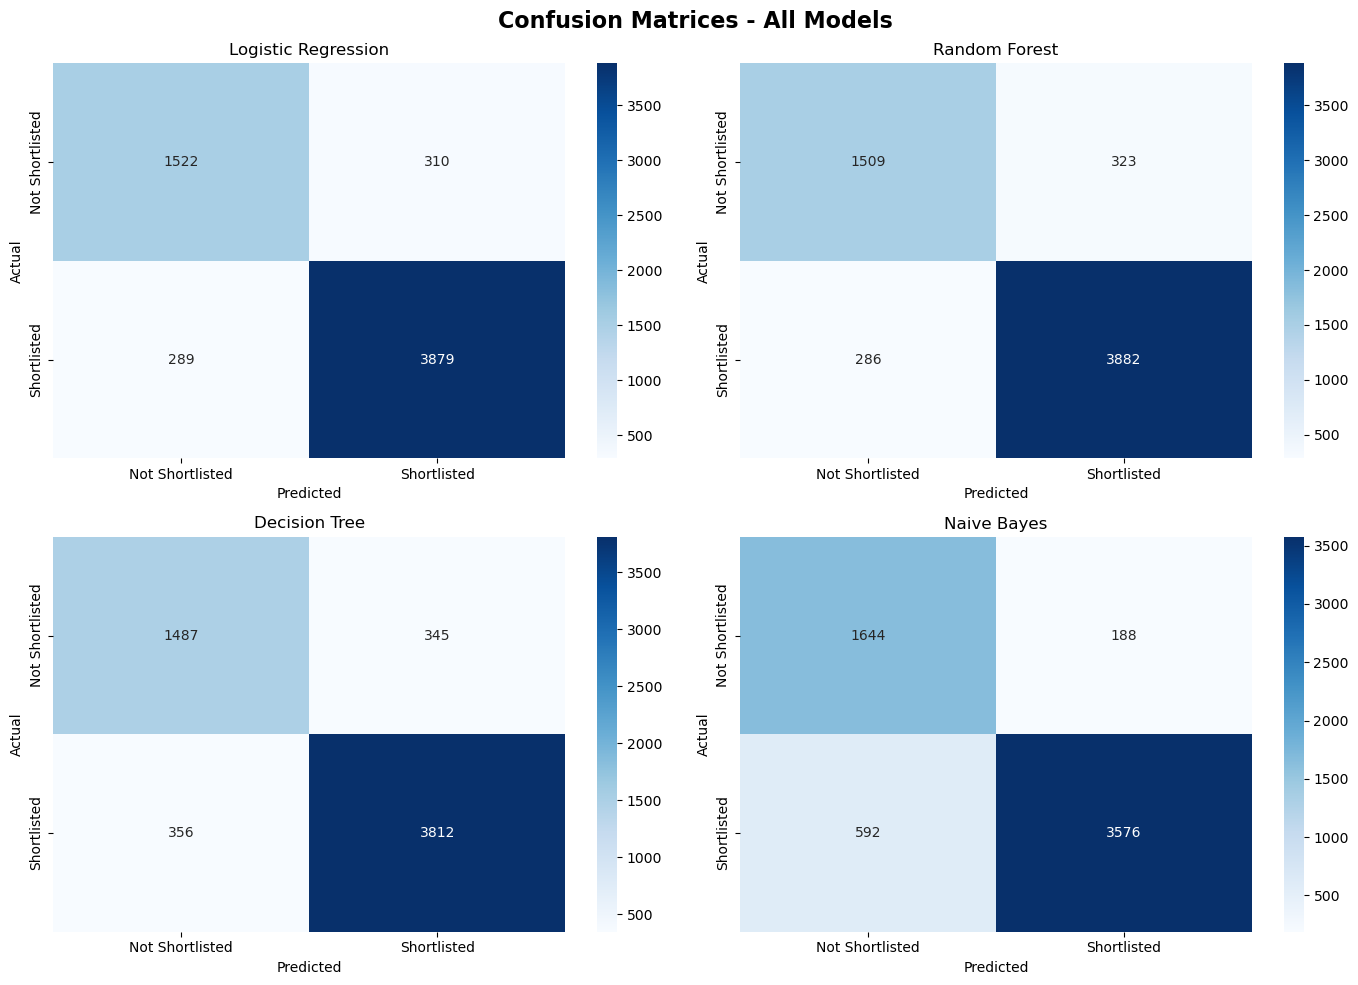

✅ Confusion matrix saved as 'confusion_matrices.png'


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Confusion Matrices - All Models", fontsize=16, fontweight='bold')

models_info = [
    ("Logistic Regression", y_pred_lr),
    ("Random Forest",       y_pred_rf),
    ("Decision Tree",       y_pred_dt),
    ("Naive Bayes",         y_pred_nb),
]

for ax, (name, y_pred) in zip(axes.flatten(), models_info):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=ax,
        xticklabels=["Not Shortlisted", "Shortlisted"],
        yticklabels=["Not Shortlisted", "Shortlisted"]
    )
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrix saved as 'confusion_matrices.png'")

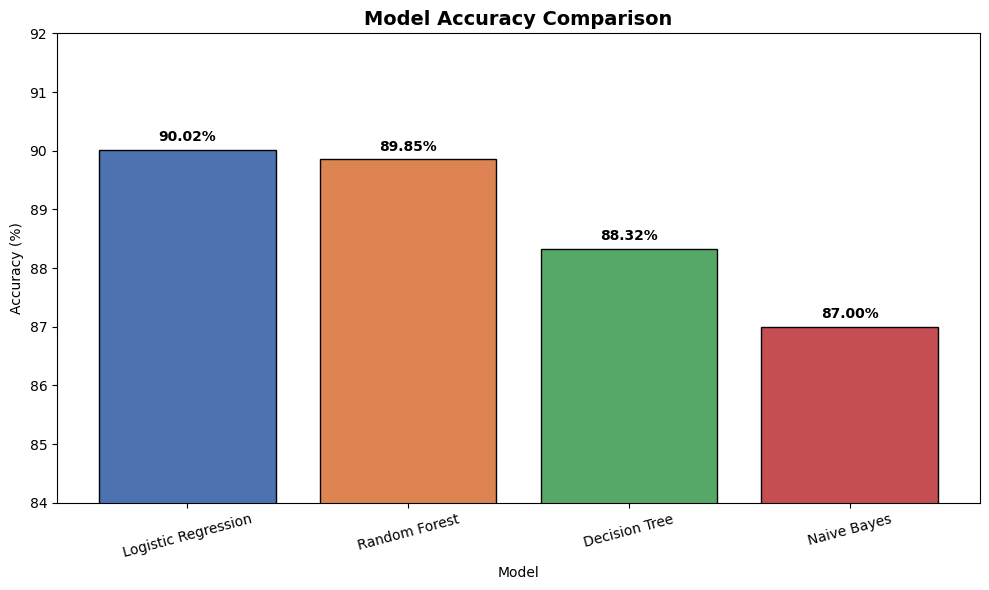

✅ Accuracy chart saved!


In [11]:
models = ["Logistic Regression", "Random Forest", "Decision Tree", "Naive Bayes"]
accuracies = [90.02, 89.85, 88.32, 87.00]
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

plt.figure(figsize=(10, 6))
bars = plt.bar(models, accuracies, color=colors, edgecolor='black')

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2., height + 0.1,
        f'{height:.2f}%',
        ha='center', va='bottom', fontweight='bold'
    )

plt.title("Model Accuracy Comparison", fontsize=14, fontweight='bold')
plt.xlabel("Model")
plt.ylabel("Accuracy (%)")
plt.ylim(84, 92)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("model_accuracy_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Accuracy chart saved!")

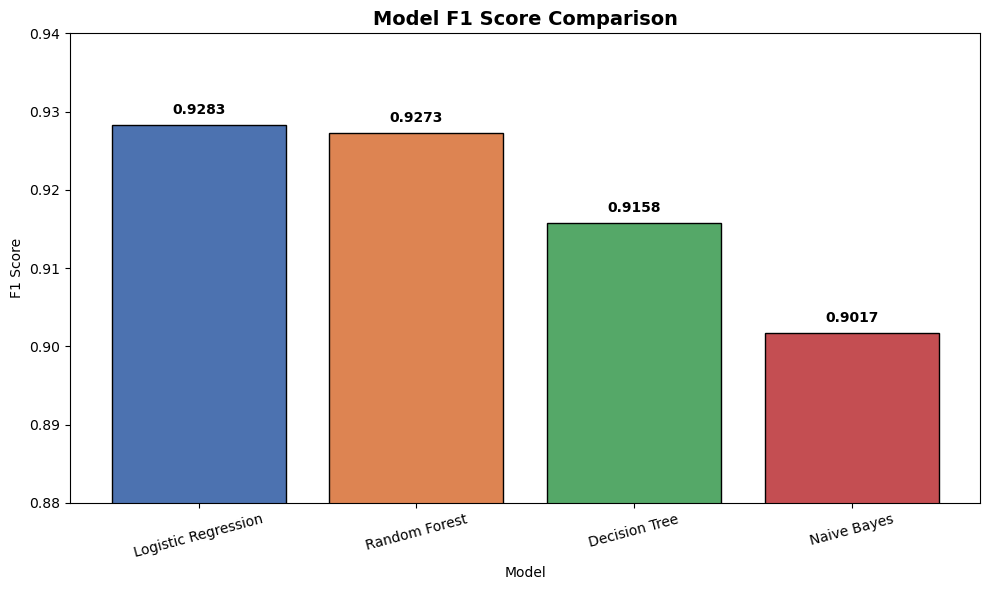

✅ F1 Score chart saved!


In [12]:
f1_scores = [0.9283, 0.9273, 0.9158, 0.9017]

plt.figure(figsize=(10, 6))
bars = plt.bar(models, f1_scores, color=colors, edgecolor='black')

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2., height + 0.001,
        f'{height:.4f}',
        ha='center', va='bottom', fontweight='bold'
    )

plt.title("Model F1 Score Comparison", fontsize=14, fontweight='bold')
plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.ylim(0.88, 0.94)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("model_f1_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ F1 Score chart saved!")

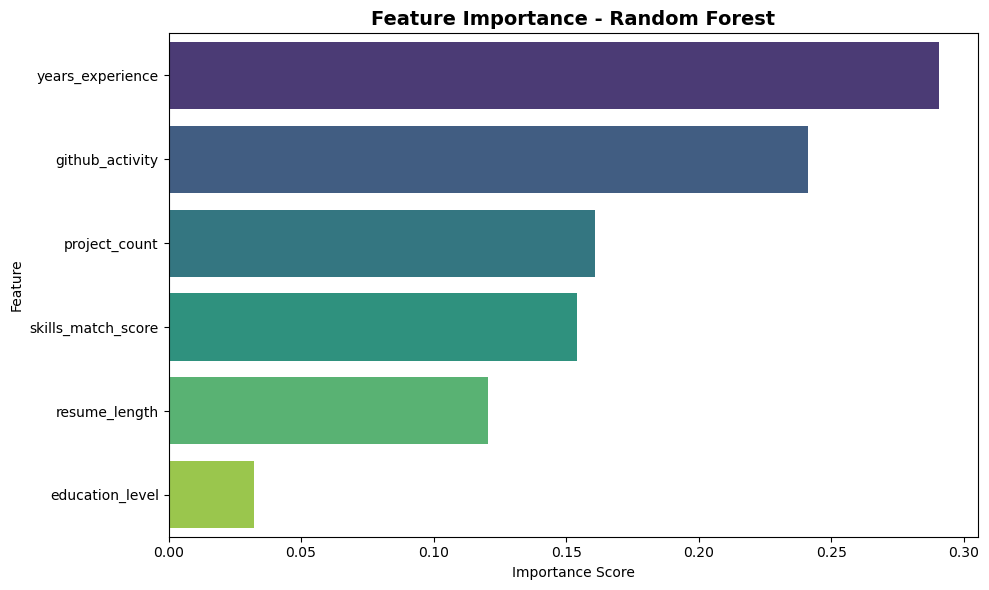

✅ Feature importance chart saved!

📌 Feature Importance Ranking:
years_experience      0.290713
github_activity       0.241355
project_count         0.160887
skills_match_score    0.154247
resume_length         0.120556
education_level       0.032243
dtype: float64


In [13]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importance.values, 
            y=feature_importance.index, 
            palette='viridis')

plt.title("Feature Importance - Random Forest", 
          fontsize=14, fontweight='bold')
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()

print("✅ Feature importance chart saved!")
print("\n📌 Feature Importance Ranking:")
print(feature_importance)

In [14]:
joblib.dump(lr_model, "best_model_lr.pkl")
joblib.dump(rf_model, "random_forest_model.pkl")
joblib.dump(dt_model, "decision_tree_model.pkl")
joblib.dump(nb_model, "naive_bayes_model.pkl")
joblib.dump(le, "label_encoder.pkl")

print("✅ All models saved!")
print("📁 Files created:")
print("   - best_model_lr.pkl       → Logistic Regression (BEST)")
print("   - random_forest_model.pkl → Random Forest")
print("   - decision_tree_model.pkl → Decision Tree")
print("   - naive_bayes_model.pkl   → Naive Bayes")
print("   - label_encoder.pkl       → Label Encoder (Yes/No converter)")

✅ All models saved!
📁 Files created:
   - best_model_lr.pkl       → Logistic Regression (BEST)
   - random_forest_model.pkl → Random Forest
   - decision_tree_model.pkl → Decision Tree
   - naive_bayes_model.pkl   → Naive Bayes
   - label_encoder.pkl       → Label Encoder (Yes/No converter)


In [15]:
loaded_model = joblib.load("best_model_lr.pkl")
loaded_le = joblib.load("label_encoder.pkl")

test_candidate = pd.DataFrame({
    "years_experience": [5],
    "skills_match_score": [85.0],
    "education_level": [2],
    "project_count": [4],
    "resume_length": [600],
    "github_activity": [150]
})

prediction = loaded_model.predict(test_candidate)
prediction_label = loaded_le.inverse_transform(prediction)
proba = loaded_model.predict_proba(test_candidate)

print("🧪 TEST PREDICTION:")
print(f"Years Experience  : 5")
print(f"Skills Match Score: 85%")
print(f"Education Level   : Master's (2)")
print(f"Project Count     : 4")
print(f"Resume Length     : 600")
print(f"GitHub Activity   : 150")
print(f"\n🎯 Prediction: {prediction_label[0]}")
print(f"📊 Confidence:")
print(f"   Not Shortlisted : {proba[0][0]*100:.1f}%")
print(f"   Shortlisted     : {proba[0][1]*100:.1f}%")

🧪 TEST PREDICTION:
Years Experience  : 5
Skills Match Score: 85%
Education Level   : Master's (2)
Project Count     : 4
Resume Length     : 600
GitHub Activity   : 150

🎯 Prediction: Yes
📊 Confidence:
   Not Shortlisted : 42.9%
   Shortlisted     : 57.1%
